In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.2 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import pandas as pd
import numpy as np
import json, re
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
# === 1. Gated Fusion Model ===
class GatedFusionModel(nn.Module):
    def __init__(self, dim_s, dim_j, dim_t, hidden, dropout):
        super().__init__()
        self.proj_s = nn.Sequential(nn.Linear(dim_s, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.proj_j = nn.Sequential(nn.Linear(dim_j, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.proj_t = nn.Sequential(nn.Linear(dim_t, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.gate_s = nn.Linear(dim_s, hidden)
        self.gate_j = nn.Linear(dim_j, hidden)
        self.gate_t = nn.Linear(dim_t, hidden)
        self.head_reg = nn.Linear(hidden, 1)
        self.head_cls = nn.Linear(hidden, 3)

    def forward(self, s, j, t):
        hs = self.proj_s(s)
        hj = self.proj_j(j)
        ht = self.proj_t(t)
        gs = torch.sigmoid(self.gate_s(s))
        gj = torch.sigmoid(self.gate_j(j))
        gt = torch.sigmoid(self.gate_t(t))
        fused = gs * hs + gj * hj + gt * ht
        return fused

    def predict(self, s, j, t):
        fused = self.forward(s, j, t)
        return self.head_reg(fused).squeeze(-1), self.head_cls(fused)

In [ ]:

class InterviewDataset(Dataset):
    def __init__(self, master_csv, jd_csv):
        df = pd.read_csv(master_csv)
        jd = pd.read_csv(jd_csv)
        df = df.merge(jd[['jd_id','jd_text_embedding']], on='jd_id', how='left')

        def parse_emb(s):
            try:
                return np.array(json.loads(s))
            except:
                parts = re.split(r'[,\s]+', s.strip().lstrip('[').rstrip(']'))
                return np.array([float(x) for x in parts if x])

        def parse_skills(s):
            return np.array(json.loads(s.replace("'", '"')))

        # 1) Define the interviewer-rating columns
        rating_cols = [
            'Ratings.Technical_Proficiency',
            'Ratings.Problem_Solving_Ability',
            'Ratings.Communication_Skills',
            'Ratings.Cultural_Team_Fit',
            'Ratings.Adaptability_Learning'
        ]
        # 2) Ensure they're numeric
        df[rating_cols] = df[rating_cols].apply(pd.to_numeric, errors='coerce').fillna(0.)

        # 3) Build your struct vector as: [skills_vec, segment_count, *ratings_vec]
        df['struct'] = df.apply(lambda r: np.concatenate([
            parse_skills(r['skills_vector']),
            [r['segment_count']],
            r[rating_cols].values.astype(float)
        ]), axis=1)

        # the rest stays the same…
        df['text'] = df['transcript_embedding'].apply(parse_emb)
        df['jd']   = df['jd_text_embedding'].  apply(parse_emb)

        df = df.dropna(subset=['struct','text','jd'])
        self.s = np.vstack(df['struct'].values).astype(np.float32)
        self.t = np.vstack(df['text'].  values).astype(np.float32)
        self.j = np.vstack(df['jd'].    values).astype(np.float32)

        self.y_reg = df['Overall_Score'].values.astype(np.float32)
        rec_cols   = ['rec_Hire','rec_Consider','rec_Reject']
        self.y_cls = df[rec_cols].values.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.y_reg)

    def __getitem__(self, idx):
        return (self.s[idx], self.j[idx], self.t[idx],
                self.y_reg[idx], self.y_cls[idx])


In [ ]:
# --- Objective Function for Optuna ---
def objective(trial):
    # Hyperparameters to tune
    hidden = trial.suggest_categorical('hidden', [64, 128, 256])
    dropout = trial.suggest_categorical('dropout', [0.1, 0.3, 0.5])
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-3)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
    lambda_ce = trial.suggest_loguniform('lambda_ce', 0.1, 10.0)
    batch_size = trial.suggest_categorical('batch_size', [16, 32])
    n_epochs = 10

    # Data & model instantiation
    dataset = InterviewDataset('FINAL_master.csv', 'jds_clean.csv')
    dim_s, dim_j, dim_t = dataset.s.shape[1], dataset.j.shape[1], dataset.t.shape[1]
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    metrics = []
    for train_idx, val_idx in kf.split(dataset):
        train_ds = Subset(dataset, train_idx)
        val_ds   = Subset(dataset, val_idx)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

        model = GatedFusionModel(dim_s, dim_j, dim_t, hidden, dropout)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        mse_loss = nn.MSELoss()
        ce_loss  = nn.CrossEntropyLoss()

        # Training loop
        for epoch in range(n_epochs):
            model.train()
            for s,j,t,y_reg,y_cls in train_loader:
                s, j, t = s.to(device), j.to(device), t.to(device)
                y_reg, y_cls = y_reg.to(device), y_cls.to(device)
                optimizer.zero_grad()
                pr, pc = model.predict(s, j, t)
                loss = mse_loss(pr, y_reg) + lambda_ce * ce_loss(pc, y_cls)
                loss.backward()
                optimizer.step()

        # Validation
        model.eval()
        y_true_reg, y_pred_reg, y_true_cls, y_pred_cls = [], [], [], []
        with torch.no_grad():
            for s,j,t,y_reg,y_cls in val_loader:
                s, j, t = s.to(device), j.to(device), t.to(device)
                y_reg, y_cls = y_reg.to(device), y_cls.to(device)
                pr, pc = model.predict(s, j, t)
                y_true_reg.extend(y_reg.cpu().numpy())
                y_pred_reg.extend(pr.cpu().numpy())
                y_true_cls.extend(y_cls.cpu().numpy())
                y_pred_cls.extend(pc.argmax(dim=1).cpu().numpy())

        mse = mean_squared_error(y_true_reg, y_pred_reg)
        rmse = np.sqrt(mse)
        acc  = accuracy_score(y_true_cls, y_pred_cls)
        # combined metric: higher is better
        metrics.append(acc + (1.0 - rmse))

    # Return mean combined metric
    return np.mean(metrics)

In [ ]:
if __name__ == "__main__":
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30, timeout=3600)
    print("Best trial:")
    print(study.best_trial.params)
    print("Best value:", study.best_value)

[I 2025-04-23 06:14:45,941] A new study created in memory with name: no-name-bca5d6af-b9ec-4a83-a281-4db683a24d83
<ipython-input-5-49f7d31039e0>:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-3)
<ipython-input-5-49f7d31039e0>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
<ipython-input-5-49f7d31039e0>:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lambda_ce = trial.suggest_loguniform('lambda_ce

Best trial:
{'hidden': 256, 'dropout': 0.1, 'lr': 0.000976778605183729, 'weight_decay': 8.064013497189763e-06, 'lambda_ce': 3.6913925653497857, 'batch_size': 16}
Best value: 1.693682751931959


start training

**BEST HYPERPARAMETERS**

{
  "hidden": 256,
  "dropout": 0.1,
  "lr": 9.94775e-4,
  "weight_decay": 4.0714e-05,
  "lambda_ce": 0.57086,
  "batch_size": 16
}


In [ ]:
# === 3. Load Dataset and Split ===
master_csv = 'FINAL_master.csv'
jd_csv     = 'jds_clean.csv'
dataset = InterviewDataset(master_csv, jd_csv)

In [ ]:
# 10% hold‑out test split
indices = np.arange(len(dataset))
train_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=42, stratify=dataset.y_cls)

train_ds = Subset(dataset, train_idx)
test_ds  = Subset(dataset, test_idx)

In [ ]:
# DataLoaders
batch_size = 16  # from Optuna best trial
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [ ]:
# --- 4. Train Final Model ---
device = torch.device('cuda')
dim_s, dim_j, dim_t = dataset.s.shape[1], dataset.j.shape[1], dataset.t.shape[1]

In [ ]:
# Best Optuna hyperparameters
hidden        = 256
dropout       = 0.1
lr            = 0.000976778605183729
weight_decay  = 8.064013497189763e-06
lambda_ce     = 3.6913925653497857
n_epochs      = 30

In [ ]:
model = GatedFusionModel(dim_s, dim_j, dim_t, hidden, dropout).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
mse_loss = nn.MSELoss()
ce_loss  = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(1, n_epochs+1):
    model.train()
    for s,j,t,y_reg,y_cls in train_loader:
        s,j,t = s.to(device), j.to(device), t.to(device)
        y_reg,y_cls = y_reg.to(device), y_cls.to(device)
        opt.zero_grad()
        pr, pc = model.predict(s,j,t)
        loss = mse_loss(pr, y_reg) + lambda_ce * ce_loss(pc, y_cls)
        loss.backward()
        opt.step()

In [ ]:
# --- 5. Evaluate on Hold‑Out Test ---
model.eval()
y_true_reg, y_pred_reg, y_true_cls, y_pred_cls = [], [], [], []
with torch.no_grad():
    for s,j,t,y_reg,y_cls in test_loader:
        s,j,t = s.to(device), j.to(device), t.to(device)
        y_reg,y_cls = y_reg.to(device), y_cls.to(device)
        pr, pc = model.predict(s,j,t)
        y_true_reg.extend(y_reg.cpu().numpy())
        y_pred_reg.extend(pr.cpu().numpy())
        y_true_cls.extend(y_cls.cpu().numpy())
        y_pred_cls.extend(pc.argmax(dim=1).cpu().numpy())

In [ ]:
test_rmse = mean_squared_error(y_true_reg, y_pred_reg)
test_rmse = np.sqrt(test_rmse)
test_acc  = accuracy_score(y_true_cls, y_pred_cls)
print(f"► Hold‑Out Test RMSE: {test_rmse:.4f}")
print(f"► Hold‑Out Test Accuracy: {test_acc:.4f}")

► Hold‑Out Test RMSE: 0.0917
► Hold‑Out Test Accuracy: 0.8710


In [ ]:
torch.save(model.state_dict(), "gated_model.pth")

Checks


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


In [ ]:
# --- 1) Re‑run test loop to capture gate weights + predictions ---
gate_s_vals, gate_j_vals, gate_t_vals = [], [], []
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for s,j,t,y_r,y_c in test_loader:
        # record true
        y_true.extend(y_r.numpy())

        # move to device
        s, j, t = s.to(device), j.to(device), t.to(device)

        # compute gate activations
        gs = torch.sigmoid(model.gate_s(s)).cpu().numpy()
        gj = torch.sigmoid(model.gate_j(j)).cpu().numpy()
        gt = torch.sigmoid(model.gate_t(t)).cpu().numpy()
        gate_s_vals.append(gs)
        gate_j_vals.append(gj)
        gate_t_vals.append(gt)

        # get regression output
        pr, _ = model.predict(s, j, t)
        y_pred.extend(pr.cpu().numpy())

# flatten lists
y_true = np.array(y_true)
y_pred = np.array(y_pred)

gate_s = np.vstack(gate_s_vals).ravel()
gate_j = np.vstack(gate_j_vals).ravel()
gate_t = np.vstack(gate_t_vals).ravel()


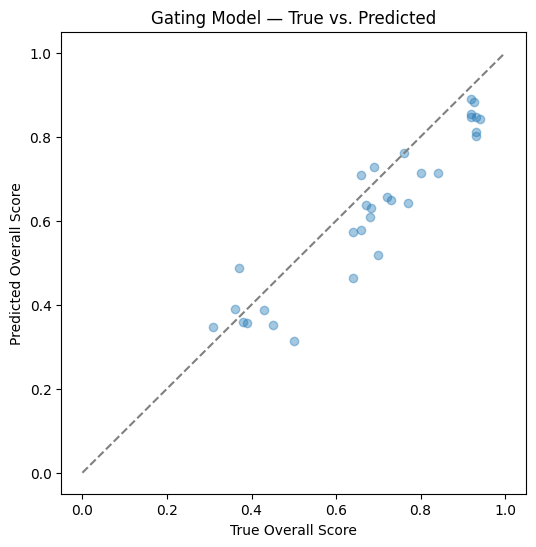

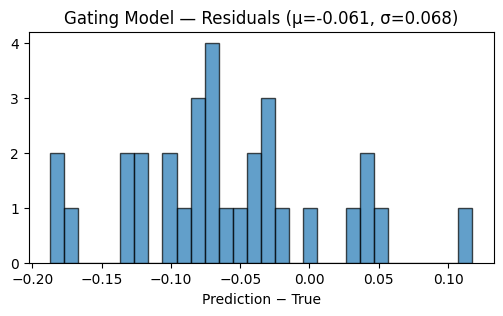

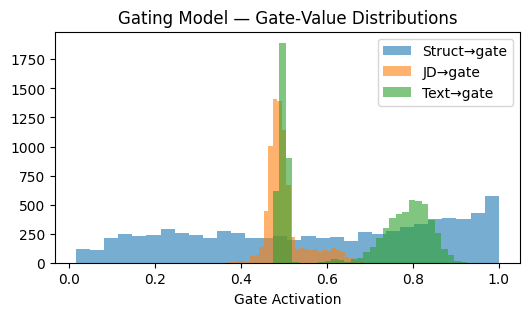

In [ ]:
# --- 2) Residual analysis ---
residuals = y_pred - y_true

# 2a) True vs. Predicted scatter
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("True Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Gating Model — True vs. Predicted")
plt.show()

# 2b) Residual histogram
plt.figure(figsize=(6,3))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
μ, σ = residuals.mean(), residuals.std()
plt.title(f"Gating Model — Residuals (μ={μ:.3f}, σ={σ:.3f})")
plt.xlabel("Prediction − True")
plt.show()

# --- 3) Gate‑value distributions ---
plt.figure(figsize=(6,3))
plt.hist(gate_s, bins=30, alpha=0.6, label='Struct→gate')
plt.hist(gate_j, bins=30, alpha=0.6, label='JD→gate')
plt.hist(gate_t, bins=30, alpha=0.6, label='Text→gate')
plt.legend()
plt.title("Gating Model — Gate‑Value Distributions")
plt.xlabel("Gate Activation")
plt.show()

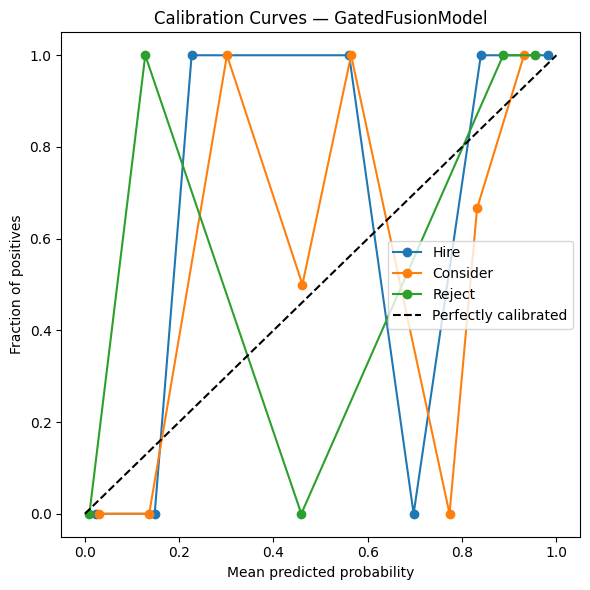

Brier score (Hire): 0.0438
Brier score (Consider): 0.0822
Brier score (Reject): 0.0395


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import torch.nn.functional as F

# — assume you already have —
#    model or gated        (GatedFusionModel, in .eval() mode)
#    test_loader           (your DataLoader over the hold‑out set)
#    device                (cpu or cuda)

# 1) Collect all predicted probabilities and true labels
probs = {0: [], 1: [], 2: []}
trues = {0: [], 1: [], 2: []}

model.eval()
with torch.no_grad():
    for s, j, t, _, y_cls in test_loader:
        s, j, t = s.to(device), j.to(device), t.to(device)
        _, logits = model.predict(s, j, t)

        p = F.softmax(logits, dim=1).cpu().numpy()  # shape (B,3)
        y = y_cls.numpy()                            # shape (B,)

        for cls_idx in (0, 1, 2):
            probs[cls_idx].extend(p[:, cls_idx])
            trues[cls_idx].extend((y == cls_idx).astype(int))

for k in probs:
    probs[k] = np.array(probs[k])
    trues[k] = np.array(trues[k])

# 2) Plot calibration curves
plt.figure(figsize=(6,6))
for cls_idx, label in enumerate(['Hire','Consider','Reject']):
    frac_pos, mean_pred = calibration_curve(
        trues[cls_idx], probs[cls_idx], n_bins=10
    )
    plt.plot(mean_pred, frac_pos, marker='o', label=label)
plt.plot([0,1],[0,1],'k--', label='Perfectly calibrated')
plt.title("Calibration Curves — GatedFusionModel")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Compute & print Brier scores
for cls_idx, label in enumerate(['Hire','Consider','Reject']):
    bs = brier_score_loss(trues[cls_idx], probs[cls_idx])
    print(f"Brier score ({label}): {bs:.4f}")
